# 02 — Ablação da recompensa e a falha do anti-short-cycling

**Perguntas:**
1. A função de recompensa proposta é de fato responsável pelo desempenho?
2. A penalidade anti-short-cycling — destacada como contribuição — cumpre o seu
   objetivo?
3. Um método tabular bastaria, dado que o espaço de estados tem 4 dimensões?

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '/home/renan/Downloads/air_conditioning_classroom/v5')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hvac import results as R
from hvac import figures as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
F.aplicar_estilo()

## 2.1 Ablação: 8 variantes × 3 sementes

Cada variante desativa **um único** mecanismo da recompensa, mantendo todo o
resto idêntico. A métrica é o conforto na faixa estreita, que discrimina regimes
onde a faixa larga satura.

**Sobre a estatística.** Com 3 sementes por grupo, o menor valor-p bicaudal
alcançável em teste de permutação é 2/C(6,3) = 0,10 — portanto p ≈ 0,101 é o
*piso*, não um resultado marginal. Por isso reportamos o δ de Cliff, tamanho de
efeito não paramétrico sem esse teto: δ = −1,00 indica **separação completa**
(toda semente ablacionada pior que toda semente da referência).

In [2]:
abl = R.ablacao()
abl[["rotulo", "media", "desvio", "minimo", "maximo", "cliffs_delta", "magnitude"]].round(2)

,rotulo,media,desvio,minimo,maximo,cliffs_delta,magnitude
0,completa (proposta),83.67,0.29,83.33,83.83,NaN,referência
1,convencional (quadrática pura),83.11,1.25,81.67,83.83,-0.11,desprezível
2,sem anti-short-cycling,83.67,0.29,83.33,83.83,0.00,desprezível
3,sem penalidade de frio,82.56,1.11,81.83,83.83,-0.56,grande
4,quadrática pura,82.33,1.59,80.67,83.83,-0.56,grande
5,sem penalidade de troca,82.06,3.08,78.50,83.83,-0.11,desprezível
6,degraus (legado),69.11,21.75,44.00,82.17,-1.00,grande
7,sem gradiente interno,47.72,13.67,34.00,61.33,-1.00,grande


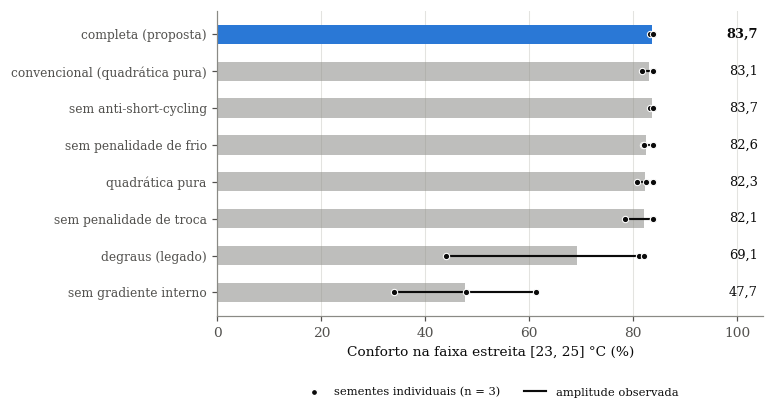

In [3]:
fig = F.fig_ablacao(abl, R.ablacao_por_semente())
plt.close(fig)
fig

### Leitura 1 — a hipótese do platô plano é confirmada

Remover o gradiente interno degrada o conforto estreito de **83,7 % para 47,7 %**
(−36 pp), com separação completa entre sementes (δ = −1,00) e treinamento
instável (desvio 13,7). Um platô verdadeiramente plano não recompensa *entrar* na
faixa — o ganho marginal junto à borda é nulo —, e a política estaciona logo
acima do teto. Este é um resultado real e defensável.

### Leitura 2 — mas a formulação proposta **não supera** a convencional

A variante `convencional` (quadrática pura, sem gradiente interno, sem penalidade
de troca, sem anti-short-cycling, sem penalidade de frio) atinge **83,1 %** contra
83,7 % da proposta: δ = −0,11, **desprezível**.

O motivo é conceitual: uma quadrática pura é uma parábola com máximo em 24 °C —
ela **já possui gradiente em todo o domínio**, por construção. O platô plano é que
o destrói; a proposta apenas o *restaura*.

**Reenquadramento necessário:** a contribuição não é uma recompensa melhor que a
da literatura. É a correção de uma falha que os próprios autores introduziram ao
adotar o platô plano. O achado publicável é *negativo*.

### Leitura 3 — cuidado ao interpretar o δ de Cliff

`sem_penal_frio` e `quadratica_pura` têm δ = −0,56, que a convenção classifica
como *grande*. Mas a diferença de média é de apenas ~1,2 pp (83,7 → 82,5). Não há
contradição: **o δ de Cliff mede separação ordinal, não magnitude da diferença.**
Um deslocamento minúsculo e consistente entre grupos produz δ alto. Reportar
apenas o δ, sem a diferença de médias ao lado, exageraria o efeito — e é por isso
que a tabela traz as duas colunas.

## 2.2 A penalidade anti-short-cycling não cumpre seu objetivo

O requisito declarado é d_min = 36 min de permanência mínima entre comutações. A
métrica agregada "comutações por hora" não permite verificá-lo: ela não distingue
"sempre respeita 36 min" de "metade das trocas viola gravemente".

In [4]:
por_agente = R.permanencia_por_agente()
por_agente[["agente", "n_comutacoes", "mediana_min", "media_min",
            "min_min", "violacoes_pct"]].round(1)

,agente,n_comutacoes,mediana_min,media_min,min_min,violacoes_pct
0,DQN Agressivo,264,12.0,36.0,12.0,83.3
1,DQN Equilibrado,168,12.0,59.8,12.0,71.4
2,DQN Passivo,170,12.0,57.7,12.0,72.9
3,Termostato,210,12.0,46.2,12.0,79.0


In [5]:
perm = R.permanencia()
perm["resumo"].round(1)

,regime,n,mediana_min,media_min,minimo_min,violacoes_pct
0,Penalidade de recompensa (eq. 5),168,12.0,59.8,12.0,71.4
1,Restrição dura (MinDwell),78,48.0,127.2,12.0,6.4


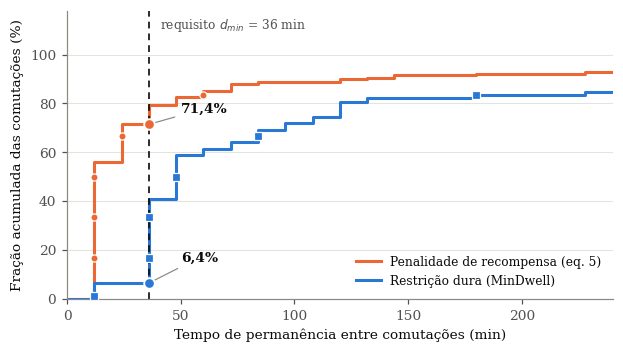

In [6]:
fig = F.fig_permanencia(perm)
plt.close(fig)
fig

### Leitura

A **mediana é 12 minutos** — uma única decisão — contra um requisito de 36. A
média de 36 a 60 minutos é inflada por longos períodos com o equipamento
desligado e **mascara completamente o problema**: é o caso didático de um agregado
que oculta a distribuição.

**Causa raiz, aritmética:** a penalidade da eq. 5 vale no máximo |ρ| = 5, contra
ganhos de conforto de até B + B_c = 14. Um termo de recompensa que pode ser
superado por outro termo não é uma proteção; é uma sugestão.

**Correção:** impondo d_min como restrição dura sobre o agente **já treinado**, sem
retreinamento, as violações caem de 71,4 % para 6,4 % e a mediana sobe de 12 para
48 minutos — mantendo o conforto binário inalterado. Os 6,4 % residuais são
artefato de medição na primeira comutação de cada episódio.

**Lição transferível:** propriedades de segurança e de integridade de hardware
devem ser impostas **estruturalmente**, não negociadas via função de recompensa.

## 2.3 Se RL for utilizado, ele precisa ser profundo

Com apenas 4 dimensões de estado, um método tabular deveria bastar. Zha et al.
(2021) fornecem a razão teórica pela qual não basta: em espaços contínuos com
variáveis de **dinâmica lenta**, a transição permanece no mesmo hiper-tile de
origem, e o valor nunca se propaga entre células.

In [7]:
tab = R.tabular()
tab.round(2)

,seed,conf_larga_pct,conf_estreita_pct,desvio_ideal,energia_kwh,cobertura_estados,intra_tile_treino_pct
0,0,31.50,19.17,3.22,12.90,76.31,59.44
1,1,38.67,22.33,4.19,10.00,76.15,59.41
2,2,56.00,40.50,2.27,12.69,76.67,59.60


In [8]:
print(f"conforto larga : {tab['conf_larga_pct'].mean():.1f}% "
      f"(desvio {tab['conf_larga_pct'].std():.1f}, por semente: "
      f"{', '.join(f'{v:.1f}' for v in tab['conf_larga_pct'])})")
print(f"intra-tile pós-treino : {tab['intra_tile_treino_pct'].mean():.1f}%")
print(f"cobertura de estados  : {tab['cobertura_estados'].mean():.1f}%")

conforto larga : 42.1% (desvio 12.6, por semente: 31.5, 38.7, 56.0)
intra-tile pós-treino : 59.5%
cobertura de estados  : 76.4%


### Leitura

| Grandeza | Valor |
|---|---|
| Espaço discretizado | 4 800 estados (20 × 10 × 24) |
| Largura do bin de temperatura | 1,00 °C |
| ΔT típico por passo (sala cheia) | 0,090 °C |
| Passos para cruzar um bin | **11,1** |
| Transições intra-tile (política aleatória) | **79,8 %** |
| Transições intra-tile (após treino) | 59,8 % |
| Cobertura de estados | 76,7 % |

Cerca de 80 % dos *backups* atualizam um estado com o próprio valor. O
Q-Learning tabular atinge **42,1 %** de conforto — **pior que o termostato de zona
morta** — e é instável entre sementes.

A queda de 80 % para 60 % após o treino ocorre porque a política aprende a usar
HIGH, que altera a temperatura rápido o bastante para cruzar bins. Ainda assim,
seis de cada dez atualizações permanecem inócuas, e ~1 100 dos 4 800 estados nunca
são visitados.

O obstáculo **não é a dimensionalidade**, e sim a razão entre o passo da dinâmica
(0,090 °C) e a resolução da discretização (1,00 °C). Este é o achado mais robusto
do conjunto: deriva inteiramente de parâmetros publicados.